#**Waves and Instabilities Project: MHD waves in a magnetic flux**

We start by importing the various libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv,kv,ivp,kvp, jv
from scipy.optimize import brentq

We define the various variables:

In [2]:
rho0=1
rhoe=0.1
cs0=0.5
cA0=1
cse=0.5
cAe=3

ct0=np.sqrt((cs0**2*cA0**2)/(cs0**2+cA0**2))
cte=np.sqrt((cse**2*cAe**2)/(cse**2+cAe**2))

We now create a function to define M0 and Me:


In [3]:
def M(vph, cs, cA, ct, kza):
  num=(cA**2-vph**2)*(cs**2-vph**2)
  den=(cs**2+cA**2)*(ct**2-vph**2)
  Mfin=(kza**2)*(num/den)
  return np.lib.scimath.sqrt(Mfin)

We can now create the function for the dispersion relation:


In [4]:
def dispersion(vph, m, kza):
  M0a=M(vph, cs0, cA0, ct0, kza)
  Mea=M(vph, cse, cAe, cte, kza)
  lhsnum=M0a*ivp(m, M0a)
  lhsden=rho0*(cA0**2-vph**2)*iv(m, M0a)
  lhs=lhsnum/lhsden
  rhsnum=Mea*kvp(m, Mea)
  rhsden=rhoe*(cAe**2-vph**2)*kv(m, Mea)
  rhs=rhsnum/rhsden
  return np.real(lhs-rhs)

In [5]:
def check(vph, m, kza):
  M0a=M(vph, cs0, cA0, ct0, kza)
  m0a=np.imag(M0a)
  return jv(m, m0a)

In [6]:
def root(m,kza):
  vscan=np.linspace(cA0+0.01, cAe-0.01, 300)
  for i in range(len(vscan)-1):
    f1=dispersion(vscan[i], m, kza)
    f2=dispersion(vscan[i+1], m, kza)
    if f1*f2<0:
      pole1=check(vscan[i], m, kza)
      pole2=check(vscan[i+1], m, kza)
      if pole1*pole2>0:
        return brentq(dispersion, vscan[i], vscan[i+1], args=(m, kza))
  return np.nan

In [7]:
kzaarray=np.linspace(0.1, 5, 80)
vsausage=[root(0,kza) for kza in kzaarray]
vkink=[root(1, kza) for kza in kzaarray]

Now we can finally plot the sausage mode (m=0):


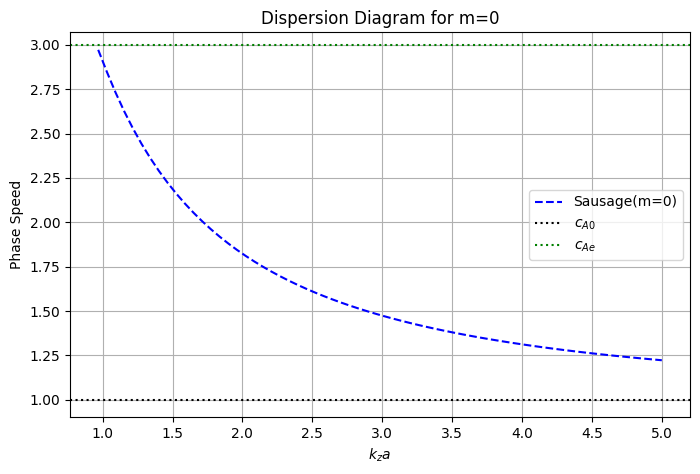

In [8]:
plt.figure(figsize=(8,5))
plt.plot(kzaarray, vsausage, 'b--', label='Sausage(m=0)')
plt.axhline(cA0, color='k', linestyle=':', label='$c_{A0}$')
plt.axhline(cAe, color='g', linestyle=':', label='$c_{Ae}$')
plt.xlabel('$k_z a$')
plt.ylabel('Phase Speed')
plt.title('Dispersion Diagram for m=0')
plt.legend()
plt.grid()
plt.show()

Now we can do the same but for the kink mode (m=1):

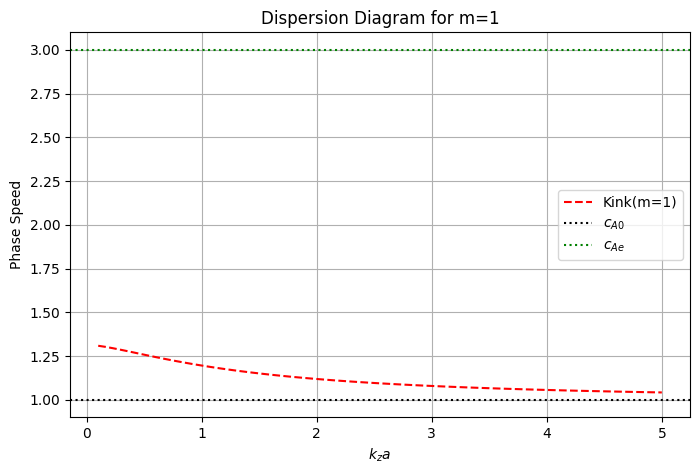

In [9]:
plt.figure(figsize=(8,5))
plt.plot(kzaarray, vkink, 'r--', label='Kink(m=1)')
plt.axhline(cA0, color='k', linestyle=':', label='$c_{A0}$')
plt.axhline(cAe, color='g', linestyle=':', label='$c_{Ae}$')
plt.xlabel('$k_z a$')
plt.ylabel('Phase Speed')
plt.title('Dispersion Diagram for m=1')
plt.legend()
plt.grid()
plt.show()

Now we can plot the eigenfunctions:

In [10]:
kzatarget=2.5
ra=np.linspace(0,3,200)

We define the function to plot the eigenfunction:

In [11]:
def ploteigen(vph, m, title):
  if np.isnan(vph):
    print(f"Not plotted outside of cutoff")
    return
  M0a=M(vph, cs0, cA0, ct0, kzatarget)
  Mea=M(vph, cse, cAe, cte, kzatarget)
  eigenP=np.zeros_like(ra, dtype=complex)
  A=1
  B=A*iv(m, M0a)/kv(m, Mea)
  for i,r in enumerate(ra):
    if r<=1.0:
      eigenP[i]=A*iv(m, M0a*r)
    else:
      eigenP[i]=B*kv(m, Mea*r)
  profile=np.real(eigenP)+np.imag(eigenP)
  plt.plot(ra, profile/np.max(np.abs(eigenP)), label=title)


In [12]:
vstarget=root(0, kzatarget)
vktarget=root(1, kzatarget)

We can now plot:

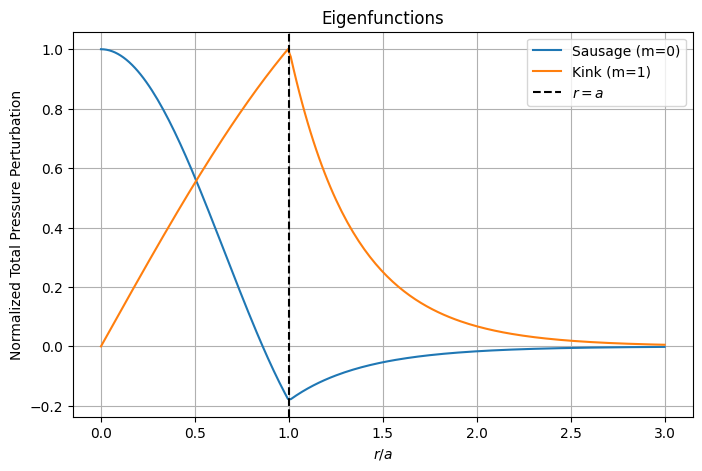

In [13]:
plt.figure(figsize=(8,5))
ploteigen(vstarget, 0, 'Sausage (m=0)')
ploteigen(vktarget, 1, 'Kink (m=1)')
plt.axvline(1.0, color='k', linestyle='--', label='$r=a$')
plt.xlabel('$r/a$')
plt.ylabel('Normalized Total Pressure Perturbation')
plt.title(f"Eigenfunctions")
plt.legend()
plt.grid()
plt.show()